# 01 — Pré-processamento do dataset LD2011_2014

**Tema:** Self-Supervised Learning for Time Series — imputação de dados faltantes.

Este notebook prepara o dataset **ElectricityLoadDiagrams20112014** (UCI) para o
pré-treino auto-supervisionado do modelo de imputação (notebook 02). O dado bruto:

- 370 clientes de energia em Portugal (`MT_001`…`MT_370`), consumo em kW;
- resolução de 15 minutos, de 2011-01-01 a 2015-01-01;
- formato: separador `;`, decimal `,`;
- **zeros no início de uma série significam que o cliente ainda não existia**
  (ausência de medição, não consumo nulo).

## Etapas do pipeline

1. **Carga + reamostragem para 1 h** (média) — reduz o comprimento das sequências 4×
   e é a resolução padrão usada na literatura com este dataset;
2. **Recorte 2012–2014 e seleção de clientes** — descarta 2011 (muitos clientes
   ainda não existiam) e clientes com mais de 5 % de zeros no período;
3. **Divisão temporal** treino/validação/teste — *por tempo*, nunca aleatória,
   para não vazar o futuro para o treino;
4. **Normalização z-score por série**, com estatísticas calculadas **apenas no treino**;
5. **Janelamento univariado** — cada série vira janelas de 168 h (1 semana).

Todas as funções vêm de [src/dados.py](src/dados.py) e são genéricas: o mesmo
pipeline se aplica a qualquer outro dataset (requisito de reprodutibilidade).


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(str(Path.cwd()))
from src import dados
from src.estilo import aplicar_estilo, PALETA

aplicar_estilo()

# configuração única do pré-processamento (salva junto com os dados)
CFG = {
    "arquivo": "LD2011_2014.txt",
    "freq": "1h",                     # reamostragem (média horária, kW)
    "inicio": "2012-01-01",           # descarta 2011
    "fim": "2014-12-31 23:00",
    "max_frac_zeros": 0.05,           # descarta clientes com >5% de zeros
    "n_clientes": 100,                # subconjunto reprodutível (semente fixa)
    "semente": 42,
    "fim_treino": "2013-12-31 23:00", # treino: 2012–2013 (2 anos)
    "fim_val": "2014-06-30 23:00",    # validação: 1º semestre de 2014
    "seq_len": 168,                   # janela de 1 semana (168 h)
    "passo_treino": 24,               # janelas sobrepostas no treino (mais dados)
    "passo_aval": 168,                # sem sobreposição na validação/teste
    "pasta_saida": "dados_processados",
}
CFG

{'arquivo': 'LD2011_2014.txt',
 'freq': '1h',
 'inicio': '2012-01-01',
 'fim': '2014-12-31 23:00',
 'max_frac_zeros': 0.05,
 'n_clientes': 100,
 'semente': 42,
 'fim_treino': '2013-12-31 23:00',
 'fim_val': '2014-06-30 23:00',
 'seq_len': 168,
 'passo_treino': 24,
 'passo_aval': 168,
 'pasta_saida': 'dados_processados'}

## 1. Carga e reamostragem

O arquivo tem ~700 MB; a leitura leva alguns minutos. A média horária preserva a
unidade (kW médio na hora).

In [2]:
%%time
bruto = dados.carregar_ld2011(CFG["arquivo"], freq=CFG["freq"])
print(f"shape horário: {bruto.shape}  |  período: {bruto.index.min()} -> {bruto.index.max()}")
bruto.iloc[:3, :5]

shape horário: (35065, 370)  |  período: 2011-01-01 00:00:00 -> 2015-01-01 00:00:00
CPU times: total: 6.67 s
Wall time: 6.71 s


,MT_001,MT_002,MT_003,MT_004,MT_005
2011-01-01 00:00:00,0.0,0.0,0.0,0.0,0.0
2011-01-01 01:00:00,0.0,0.0,0.0,0.0,0.0
2011-01-01 02:00:00,0.0,0.0,0.0,0.0,0.0


## 2. Recorte do período e seleção de clientes

Mantemos 2012–2014 e clientes com no máximo 5 % de zeros no período (zeros em
excesso indicam cliente inexistente/medição ausente). Dos elegíveis, sorteamos
100 com semente fixa — qualquer pessoa que rode este notebook obtém exatamente
o mesmo subconjunto.

In [3]:
df = dados.selecionar_clientes(
    bruto, CFG["inicio"], CFG["fim"],
    max_frac_zeros=CFG["max_frac_zeros"],
    n_clientes=CFG["n_clientes"],
    semente=CFG["semente"],
)
frac_zeros_total = (bruto.loc[CFG["inicio"]:CFG["fim"]] == 0).mean()
print(f"clientes elegíveis (<= 5% zeros): {(frac_zeros_total <= CFG['max_frac_zeros']).sum()} de {bruto.shape[1]}")
print(f"clientes selecionados: {df.shape[1]}  |  passos horários: {len(df)}")

clientes elegíveis (<= 5% zeros): 314 de 370
clientes selecionados: 100  |  passos horários: 26304


## 3. Exploração visual

Duas semanas de três clientes: os padrões que o modelo terá de aprender para
imputar — **sazonalidade diária** (dia/noite) e **semanal** (dias úteis × fim de
semana) — são visíveis a olho nu.

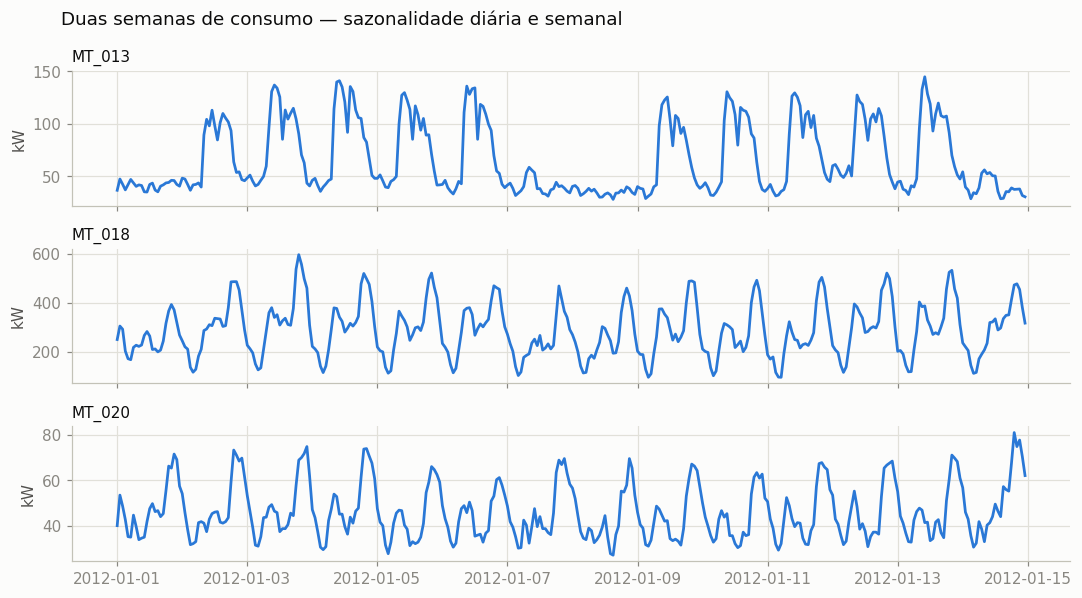

In [4]:
recorte = df.iloc[: 24 * 14]
clientes_ex = df.columns[:3]

fig, eixos = plt.subplots(3, 1, figsize=(10, 5.5), sharex=True)
for eixo, cli in zip(eixos, clientes_ex):
    eixo.plot(recorte.index, recorte[cli], color=PALETA["azul"])
    eixo.set_title(cli, loc="left", fontsize=10)
    eixo.set_ylabel("kW")
fig.suptitle("Duas semanas de consumo — sazonalidade diária e semanal", x=0.06, ha="left")
fig.tight_layout()
plt.show()

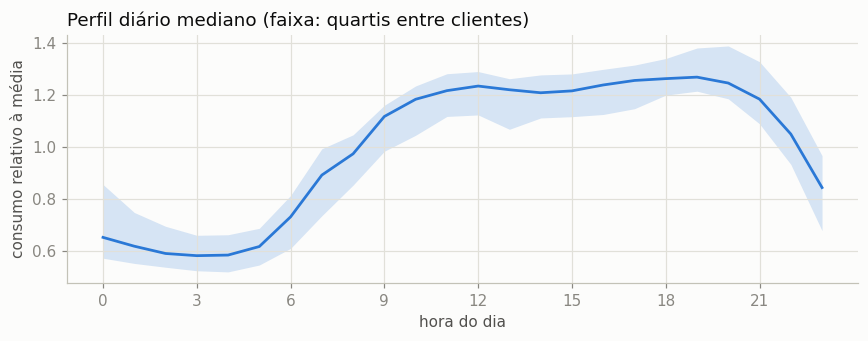

In [5]:
# perfil diário: consumo médio por hora do dia, relativo à média de cada cliente
perfil = df.groupby(df.index.hour).mean()
perfil_rel = perfil / perfil.mean()

fig, eixo = plt.subplots(figsize=(8, 3.2))
q1 = perfil_rel.quantile(0.25, axis=1)
q3 = perfil_rel.quantile(0.75, axis=1)
eixo.fill_between(perfil_rel.index, q1, q3, color=PALETA["azul"], alpha=0.18, linewidth=0)
eixo.plot(perfil_rel.index, perfil_rel.median(axis=1), color=PALETA["azul"])
eixo.set_xlabel("hora do dia")
eixo.set_ylabel("consumo relativo à média")
eixo.set_title("Perfil diário mediano (faixa: quartis entre clientes)", loc="left")
eixo.set_xticks(range(0, 24, 3))
fig.tight_layout()
plt.show()

## 4. Divisão temporal treino / validação / teste

Em séries temporais a divisão deve ser **por tempo**: o modelo é treinado no
passado e avaliado no futuro. Divisão aleatória vazaria janelas do futuro para o
treino (janelas vizinhas se sobrepõem).

| Partição | Período | Uso |
|---|---|---|
| treino | 2012-01 → 2013-12 (2 anos) | pré-treino auto-supervisionado |
| validação | 2014-01 → 2014-06 | early stopping / escolha do melhor modelo |
| teste | 2014-07 → 2014-12 | avaliação final (notebook 03), tocado uma única vez |

In [6]:
treino, val, teste = dados.dividir_temporal(df, CFG["fim_treino"], CFG["fim_val"])
for nome, parte in [("treino", treino), ("validação", val), ("teste", teste)]:
    print(f"{nome:10s} {parte.index.min()} -> {parte.index.max()}   ({len(parte):6d} h, {len(parte)/len(df):5.1%})")

treino     2012-01-01 00:00:00 -> 2013-12-31 23:00:00   ( 17544 h, 66.7%)
validação  2014-01-01 00:00:00 -> 2014-06-30 23:00:00   (  4344 h, 16.5%)
teste      2014-07-01 00:00:00 -> 2014-12-31 23:00:00   (  4416 h, 16.8%)


## 5. Normalização (z-score por série, estatísticas do treino)

Cada cliente tem escala própria (dezenas a milhares de kW); sem normalização, os
clientes grandes dominariam a perda. Usamos z-score **por série**, com média e
desvio calculados **somente na partição de treino** — usar o período todo
vazaria informação do futuro. As estatísticas são salvas para desnormalizar as
previsões depois.

In [7]:
stats = dados.ajustar_normalizador(treino)
treino_n = dados.normalizar(treino, stats)
val_n = dados.normalizar(val, stats)
teste_n = dados.normalizar(teste, stats)
stats.describe().round(1)

,media,desvio
count,100.0,100.0
mean,329.6,125.6
std,571.5,281.3
min,8.2,2.3
25%,79.4,29.4
50%,152.4,54.2
75%,291.8,107.2
max,4050.2,2483.3


## 6. Janelamento univariado (canal-independente)

Cada série vira janelas de **168 h (1 semana)** — longas o bastante para conter
os dois ciclos sazonais. A abordagem é **univariada**: o modelo vê uma série por
vez, e portanto **independe do número de séries do dataset** — é o que permite
aplicá-lo depois a qualquer outro conjunto de dados sem mudar a arquitetura.

- treino: passo 24 h (janelas sobrepostas → ~8× mais exemplos);
- validação/teste: passo 168 h (sem sobreposição → avaliação honesta, sem
  contar o mesmo ponto duas vezes).

In [8]:
j_treino, id_treino = dados.janelar(treino_n, CFG["seq_len"], CFG["passo_treino"])
j_val, id_val = dados.janelar(val_n, CFG["seq_len"], CFG["passo_aval"])
j_teste, id_teste = dados.janelar(teste_n, CFG["seq_len"], CFG["passo_aval"])
print(f"janelas de treino:    {j_treino.shape}")
print(f"janelas de validação: {j_val.shape}")
print(f"janelas de teste:     {j_teste.shape}")

janelas de treino:    (72500, 168)
janelas de validação: (2500, 168)
janelas de teste:     (2600, 168)


## 7. Salvar artefatos

Tudo o que os notebooks seguintes precisam fica em `dados_processados/`:
`janelas.npz` (arrays), `normalizador.json` (média/desvio por cliente) e
`config_dados.json` (esta configuração, para auditoria/reprodução).

In [9]:
CFG["clientes"] = list(df.columns)
dados.salvar_processado(
    CFG["pasta_saida"], CFG, stats,
    treino=j_treino, id_treino=id_treino,
    val=j_val, id_val=id_val,
    teste=j_teste, id_teste=id_teste,
)
for p in sorted(Path(CFG["pasta_saida"]).iterdir()):
    print(f"{p.name:25s} {p.stat().st_size/1e6:8.1f} MB")

config_dados.json              0.0 MB
janelas.npz                    6.7 MB
normalizador.json              0.0 MB


---
**Próximo passo:** [02_treinamento.ipynb](02_treinamento.ipynb) — definição do
modelo BERT e pré-treino auto-supervisionado com reconstrução mascarada.